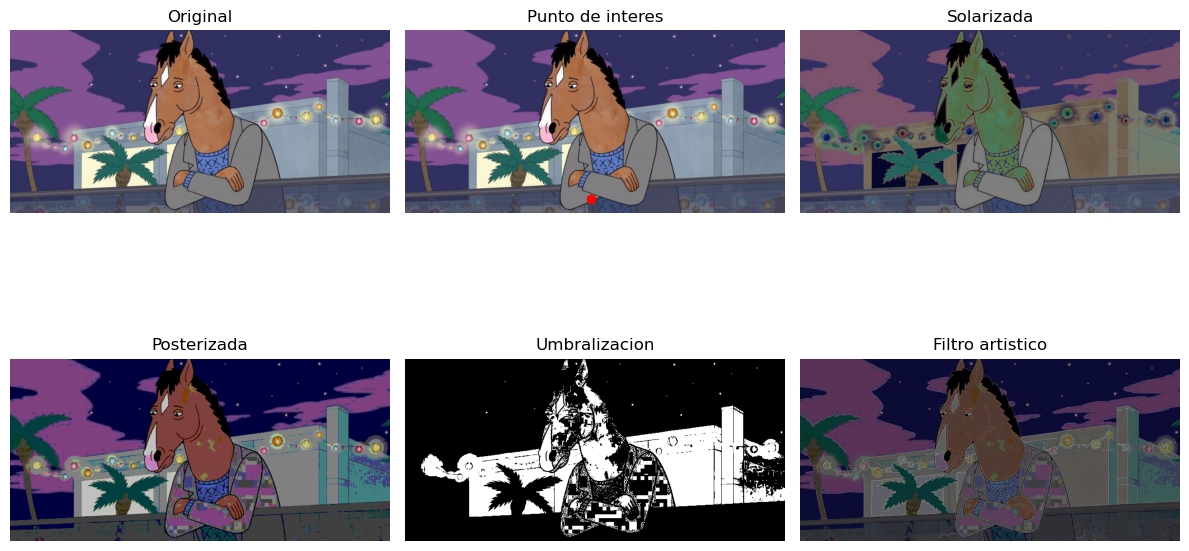

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

def posterizar(imagen, niveles):
    factor_escala = 255 / niveles
    img_pos = np.round(imagen / factor_escala) * factor_escala
    return img_pos.astype(np.uint8)

def solarizar(imagen, umbral):
    return np.where(imagen < umbral, imagen, 255 - imagen).astype(np.uint8)

img = cv2.imread('imagen1.jpg')

alto, ancho, _ = img.shape

x = random.randint(0, ancho - 100)
y = random.randint(0, alto - 100)

img_recortada = img[y:y+100, x:x+100]

img_solarizada = solarizar(img_recortada, 128)
img_posterizada = posterizar(img_recortada, 4)

gris = cv2.cvtColor(img_recortada, cv2.COLOR_BGR2GRAY)
_, img_umbral = cv2.threshold(gris, 127, 255, cv2.THRESH_BINARY)

bordes = cv2.Canny(gris, 100, 200)
bordes_color = cv2.cvtColor(bordes, cv2.COLOR_GRAY2BGR)

filtro_artistico = cv2.addWeighted(img_posterizada, 0.6, img_solarizada, 0.3, 0)
filtro_artistico = cv2.addWeighted(filtro_artistico, 0.8, bordes_color, 0.2, 0)

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.title('Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,3,2)
plt.title('Punto de interes (recorte)')
plt.imshow(cv2.cvtColor(img_recortada, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,3,3)
plt.title('Solarizada')
plt.imshow(cv2.cvtColor(img_solarizada, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,3,4)
plt.title('Posterizada')
plt.imshow(cv2.cvtColor(img_posterizada, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2,3,5)
plt.title('Umbralizacion')
plt.imshow(img_umbral, cmap='gray')
plt.axis('off')

plt.subplot(2,3,6)
plt.title('Filtro artistico')
plt.imshow(cv2.cvtColor(filtro_artistico, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

cv2.imwrite('01_original.jpg', img)
cv2.imwrite('02_punto_interes_recorte.jpg', img_recortada)
cv2.imwrite('03_solarizada.jpg', img_solarizada)
cv2.imwrite('04_posterizada.jpg', img_posterizada)
cv2.imwrite('05_umbral.jpg', img_umbral)
cv2.imwrite('06_filtro_artistico.jpg', filtro_artistico)

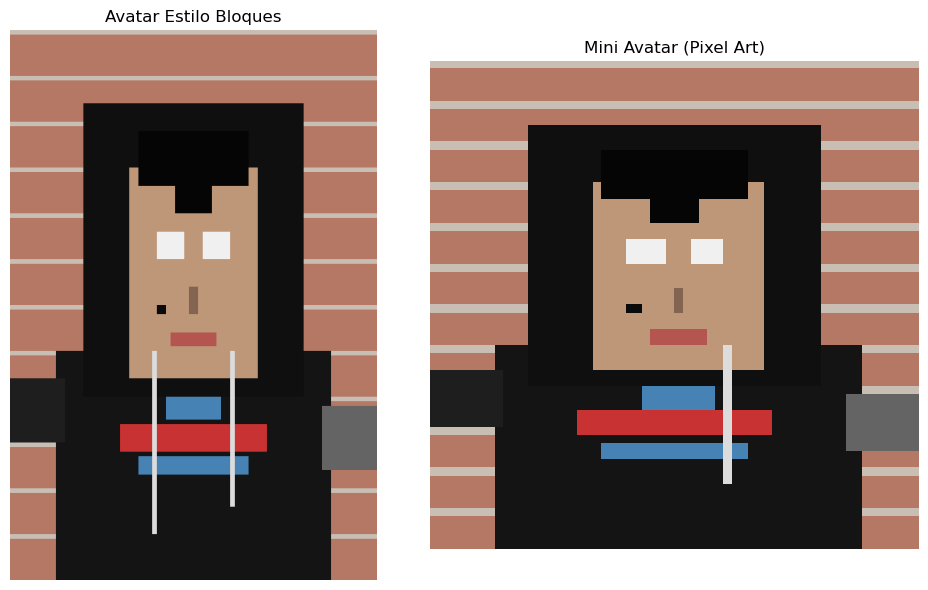

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = np.zeros((600, 400, 3), dtype=np.uint8)

img[:, :] = [100, 120, 180] 

for i in range(0, 600, 50):
    img[i:i+5, :] = [180, 190, 200]

img[350:600, 50:350] = [20, 20, 20] 

img[80:400, 80:320] = [15, 15, 15]

img[150:380, 130:270] = [120, 150, 190] 
img[220:250, 160:190] = [240, 240, 240]
img[220:250, 210:240] = [240, 240, 240] 

img[280:310, 195:205] = [80, 100, 130] 
img[330:345, 175:225] = [80, 85, 180]   
img[300:310, 160:170] = [10, 10, 10]   
img[110:170, 140:260] = [5, 5, 5]
img[140:200, 180:220] = [5, 5, 5] 

img[430:460, 120:280] = [50, 50, 200] 

img[400:425, 170:230] = [180, 130, 70] 
img[465:485, 140:260] = [180, 130, 70] 


img[350:550, 155:160] = [220, 220, 220]
img[350:520, 240:245] = [220, 220, 220]

img[380:450, 0:60] = [30, 30, 30] 
img[410:480, 340:400] = [100, 100, 100]


img_small = cv2.resize(img, (60, 60), interpolation=cv2.INTER_NEAREST)


plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.title("Avatar Estilo Bloques")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Mini Avatar (Pixel Art)")
plt.imshow(cv2.cvtColor(img_small, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()